# 03 - Modelado y Evaluación

Objetivo: entrenar modelos base, comparar métricas y analizar resultados.

In [68]:
# Importar librerías y cargar datasets procesados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

processed_dir = "../data/processed"
df_encoded = pd.read_csv(f"{processed_dir}/df_encoded.csv")
X_train = pd.read_csv(f"{processed_dir}/X_train.csv")
X_test = pd.read_csv(f"{processed_dir}/X_test.csv")
y_train = pd.read_csv(f"{processed_dir}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{processed_dir}/y_test.csv").squeeze()

## Modelo A: LinearRegression (target sin log)

In [69]:
# Regresión lineal: escalar variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
# Regresión lineal: entrenar
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [71]:
# Regresión lineal: predecir
lr_pred = lr_model.predict(X_test_scaled)

In [72]:
# Regresión lineal: métricas
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = root_mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

MAE: 20607.582950179472
RMSE: 52614.109588040956
R²: 0.6390968971895188


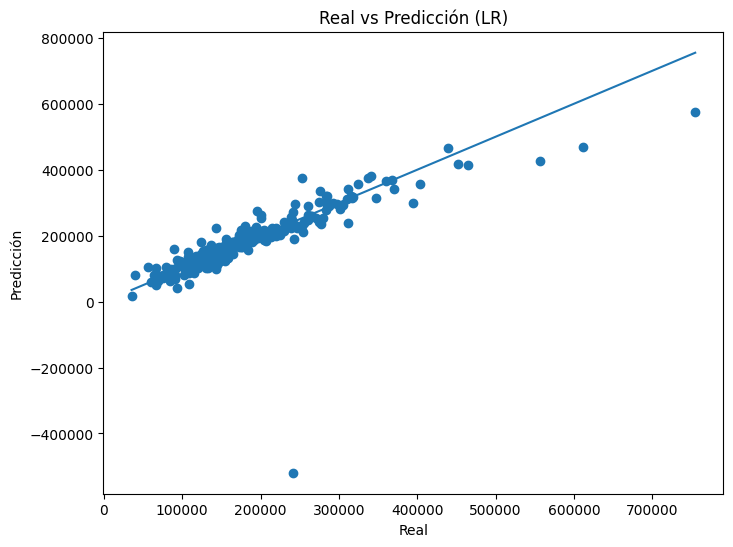

In [73]:
# Regresión lineal: real vs predicción
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción (LR)")
plt.show()

## Modelo B: RandomForest (target sin log)

In [74]:
# Random Forest: entrenar
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [75]:
# Random Forest: predecir
rf_pred = rf_model.predict(X_test)

In [76]:
# Random Forest: métricas
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 17814.268630136983
RMSE: 29408.882077621667
R²: 0.8872430817551072


In [77]:
# Random Forest: importancia de variables
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

        Feature  Importance
4   OverallQual    0.559389
16    GrLivArea    0.121035
14     2ndFlrSF    0.035108
12  TotalBsmtSF    0.034127
9    BsmtFinSF1    0.029384
13     1stFlrSF    0.026776
3       LotArea    0.017382
27   GarageArea    0.015495
26   GarageCars    0.012695
6     YearBuilt    0.012543


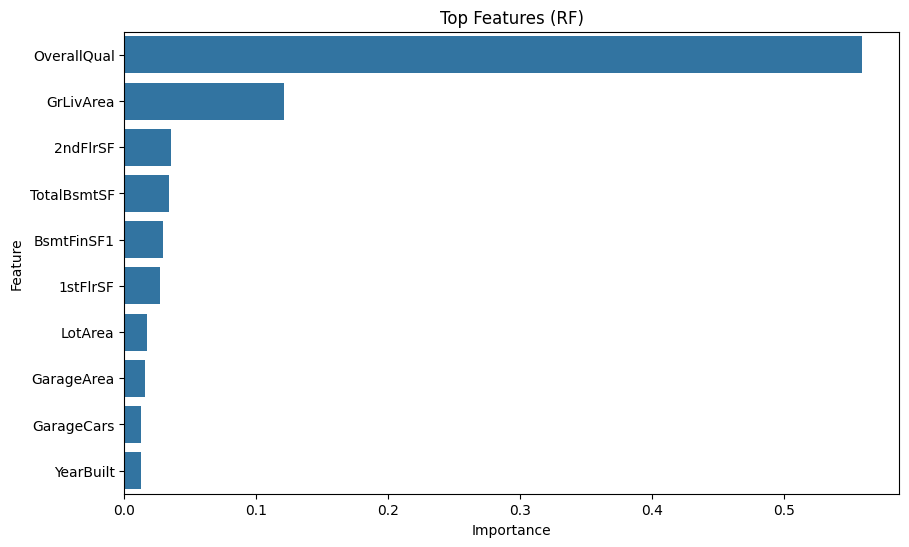

In [78]:
# Random Forest: top features
top10 = importance.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=top10)
plt.title("Top Features (RF)")
plt.show()

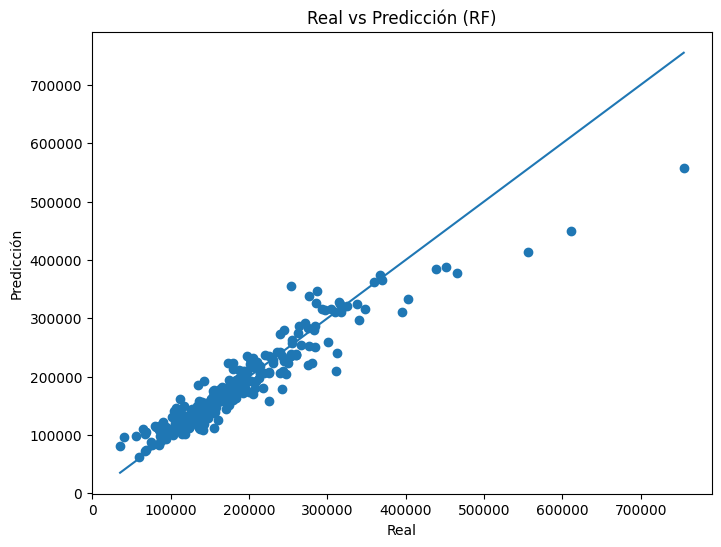

In [79]:
# Random Forest: real vs predicción
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción (RF)")
plt.show()

In [80]:
# Random Forest: validación cruzada
from sklearn.model_selection import cross_val_score

X_full = df_encoded.drop(["SalePrice"], axis=1)
y_full = df_encoded["SalePrice"]
scores = cross_val_score(rf_model, X_full, y_full, cv=10, scoring="r2")

print(scores)
print("Promedio:", scores.mean())
print("Desviación estándar:", scores.std())

[0.86114515 0.88783403 0.91886448 0.76304753 0.88607982 0.88905025
 0.87559565 0.88213993 0.77568501 0.85460989]
Promedio: 0.8594051736048266
Desviación estándar: 0.04799256218560362


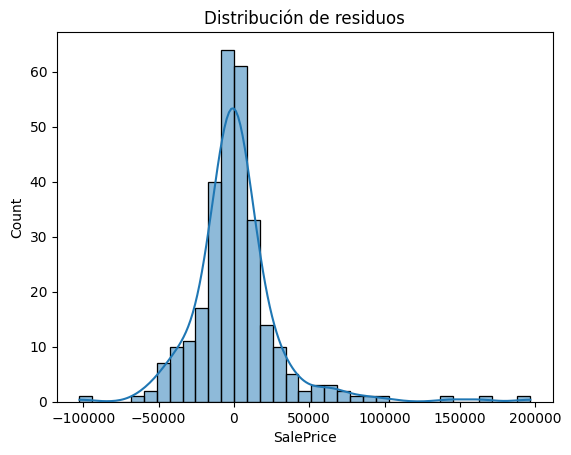

In [81]:
# Random Forest: análisis de residuos
residuos = y_test - rf_pred
sns.histplot(residuos, kde=True)
plt.title("Distribución de residuos")
plt.show()

## Modelo C: LinearRegression (target con log)

In [ ]:
# Entrenamiento con logaritmo
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_model_log = LinearRegression()
lr_model_log.fit(X_train_scaled, y_train_log)
lr_pred_log = lr_model_log.predict(X_test_scaled)
lr_log_pred = np.expm1(lr_pred_log)

In [83]:
# Evaluación del modelo con logaritmo
lr_mae_log = mean_absolute_error(y_test, lr_log_pred)
lr_rmse_log = root_mean_squared_error(y_test, lr_log_pred)
lr_r2_log = r2_score(y_test, lr_log_pred)
print("MAE (log):", lr_mae_log)
print("RMSE (log):", lr_rmse_log)
print("R² (log):", lr_r2_log)

MAE (log): 15526.26198173482
RMSE (log): 25788.448882885914
R² (log): 0.913296504239667


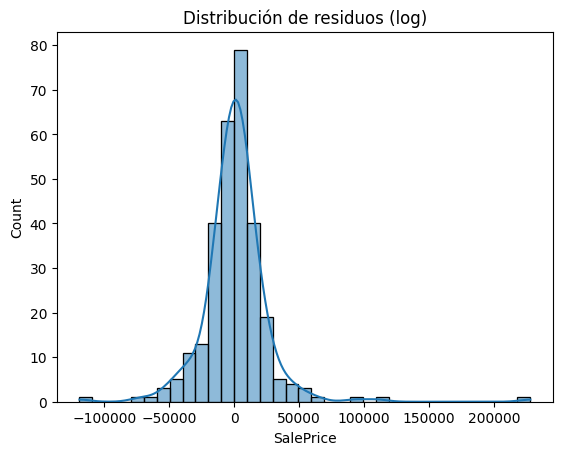

In [85]:
# Analisis de residuos (log)
residuos_log = y_test - lr_log_pred
sns.histplot(residuos_log, kde=True)
plt.title("Distribución de residuos (log)")
plt.show()

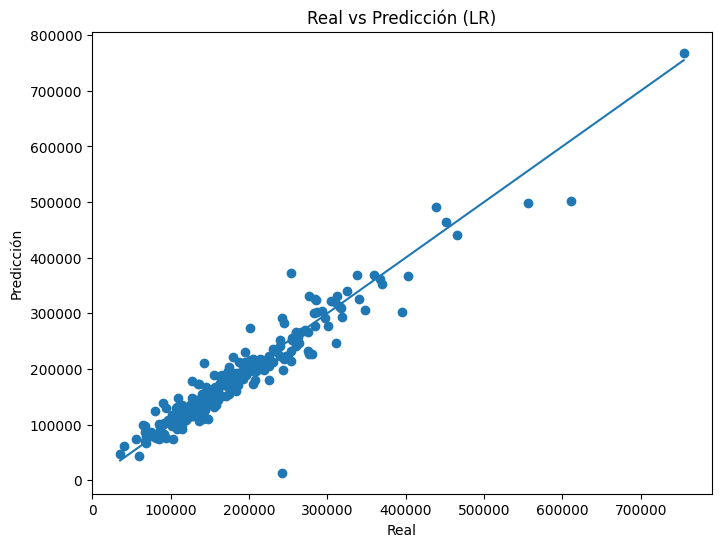

In [88]:
# Regresión lineal: real vs predicción
import os

plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_log_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción (LR)")

figures_dir = "../reports/figures"
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(f"{figures_dir}/lr_real_vs_pred_log.png")
plt.show()

## Modelo D: RandomForest (target con log)

In [ ]:
# Entrenamiento con logaritmo
rf_model_log = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_log.fit(X_train, y_train_log)
rf_log_pred_log = rf_model_log.predict(X_test)
rf_log_pred = np.expm1(rf_log_pred_log)

In [87]:
# Evaluación del modelo con logaritmo
rf_mae_log = mean_absolute_error(y_test, rf_log_pred)
rf_rmse_log = root_mean_squared_error(y_test, rf_log_pred)
rf_r2_log = r2_score(y_test, rf_log_pred)
print("MAE (log):", rf_mae_log)
print("RMSE (log):", rf_rmse_log)
print("R² (log):", rf_r2_log)

MAE (log): 17718.628547049517
RMSE (log): 29430.28324377327
R² (log): 0.8870789131501156


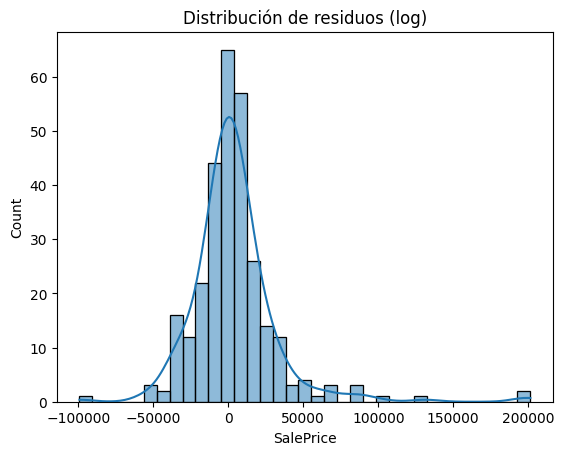

In [89]:
# Analisis de residuos (log)
residuos_rf_log = y_test - rf_log_pred
sns.histplot(residuos_rf_log, kde=True)
plt.title("Distribución de residuos (log)")
plt.show()

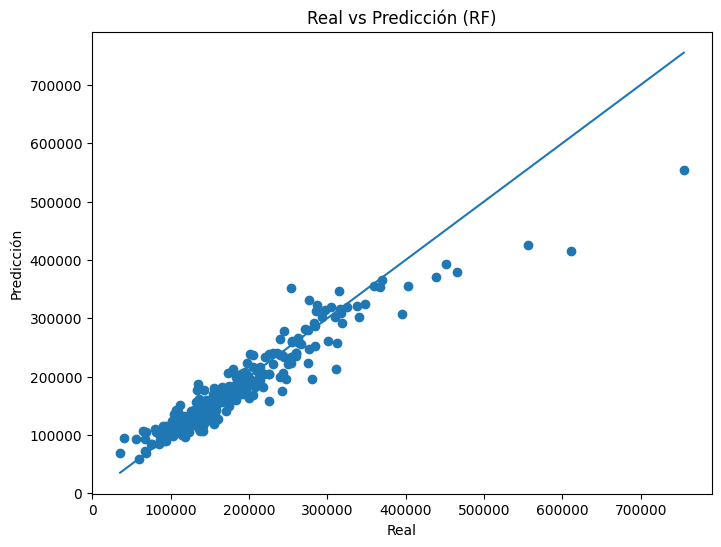

In [90]:
# Real vs predicción (log)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_log_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción (RF)")
plt.show()

In [91]:
# Interpretabilidad
coeficientes_rf_log = rf_model_log.feature_importances_
coeficientes_rf_log_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": coeficientes_rf_log
}).sort_values("Importance", ascending=False)
print(coeficientes_rf_log_df.head(10))

          Feature  Importance
4     OverallQual    0.547866
16      GrLivArea    0.113214
12    TotalBsmtSF    0.043499
26     GarageCars    0.041657
9      BsmtFinSF1    0.022563
27     GarageArea    0.022427
13       1stFlrSF    0.020092
193  CentralAir_Y    0.016613
3         LotArea    0.015579
6       YearBuilt    0.013942


In [95]:
# Cross-validation con logaritmo
scores_rf_log = cross_val_score(rf_model_log, X_full, y_full, cv=10, scoring="r2")
print(f"Cross-validation scores (Random Forest with log): {scores_rf_log}")
print(f"Promedio: {scores_rf_log.mean()}")
print(f"Desviación estándar: {scores_rf_log.std()}")


Cross-validation scores (Random Forest with log): [0.86114515 0.88783403 0.91886448 0.76304753 0.88607982 0.88905025
 0.87559565 0.88213993 0.77568501 0.85460989]
Promedio: 0.8594051736048266
Desviación estándar: 0.04799256218560362


In [96]:
# Overfitting vs underfitting
train_score = rf_model_log.score(X_train, y_train_log)
test_score = rf_model_log.score(X_test, y_test_log)
print(f"Train R²: {train_score}")
print(f"Test R²: {test_score}")


Train R²: 0.9810609324770128
Test R²: 0.882692388709982
